In [1]:
%pip install pandas numpy matplotlib seaborn plotly

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')
%matplotlib inline
pd.set_option('display.max_columns', 26)

In [3]:
df=pd.read_csv('kidney_disease.csv')

In [4]:
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,36.0,1.2,NaN,NaN,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,18.0,0.8,NaN,NaN,11.3,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,53.0,1.8,NaN,NaN,9.6,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,56.0,3.8,111.0,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,26.0,1.4,NaN,NaN,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


In [5]:
df.tail()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
395,395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,49.0,0.5,150.0,4.9,15.7,47,6700,4.9,no,no,no,good,no,no,notckd
396,396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,31.0,1.2,141.0,3.5,16.5,54,7800,6.2,no,no,no,good,no,no,notckd
397,397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,26.0,0.6,137.0,4.4,15.8,49,6600,5.4,no,no,no,good,no,no,notckd
398,398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,50.0,1.0,135.0,4.9,14.2,51,7200,5.9,no,no,no,good,no,no,notckd
399,399,58.0,80.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,131.0,18.0,1.1,141.0,3.5,15.8,53,6800,6.1,no,no,no,good,no,no,notckd


In [6]:
df.shape

(400, 26)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    str    
 7   pc              335 non-null    str    
 8   pcc             396 non-null    str    
 9   ba              396 non-null    str    
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    str    
 17  wc              295 non-null    str    
 18  r

In [8]:
columns_map = {"id": "id","age": "age","bp": "blood_pressure","sg": "specific_gravity","al": "albumin","su": "sugar","rbc": "red_blood_cells","pc": "pus_cell","pcc": "pus_cell_clumps","ba": "bacteria","bgr": "blood_glucose_random","bu": "blood_urea","sc": "serum_creatinine","sod": "sodium","pot": "potassium","hemo": "hemoglobin","pcv": "packed_cell_volume","wc": "white_blood_cell_count","rc": "red_blood_cell_count","htn": "hypertension","dm": "diabetes_mellitus","cad": "coronary_artery_disease","appet": "appetite","pe": "pedal_edema","ane": "anemia","classification": "classification",
}
df.rename(columns=columns_map, inplace=True)

In [9]:
df.isnull().sum()

id                           0
age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
hemoglobin                  52
packed_cell_volume          70
white_blood_cell_count     105
red_blood_cell_count       130
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       1
classification               0
dtype: int64

In [10]:
df.isnull().sum() / df.shape[0] *100

id                          0.00
age                         2.25
blood_pressure              3.00
specific_gravity           11.75
albumin                    11.50
sugar                      12.25
red_blood_cells            38.00
pus_cell                   16.25
pus_cell_clumps             1.00
bacteria                    1.00
blood_glucose_random       11.00
blood_urea                  4.75
serum_creatinine            4.25
sodium                     21.75
potassium                  22.00
hemoglobin                 13.00
packed_cell_volume         17.50
white_blood_cell_count     26.25
red_blood_cell_count       32.50
hypertension                0.50
diabetes_mellitus           0.50
coronary_artery_disease     0.50
appetite                    0.25
pedal_edema                 0.25
anemia                      0.25
classification              0.00
dtype: float64

pus_cell_clumps             

In [11]:
df.pus_cell_clumps=df.pus_cell_clumps.fillna(df.pus_cell_clumps.mode()[0])

pus_cell

In [12]:
df.groupby(['pus_cell','pus_cell_clumps'])['id'].count().reset_index()

,pus_cell,pus_cell_clumps,id
0,abnormal,notpresent,43
1,abnormal,present,33
2,normal,notpresent,251
3,normal,present,8


In [13]:
conditions = [
    (df["pus_cell"].isna()) & (df["pus_cell_clumps"] == "present"),
    (df["pus_cell"].isna()) & (df["pus_cell_clumps"] == "notpresent"),
]

choices = ["abnormal", "normal"]

df["pus_cell"] = np.select(conditions, choices, default=df["pus_cell"])

bacteria

In [14]:
df.groupby(['pus_cell','pus_cell_clumps'])['bacteria'].transform(lambda x :x.fillna(x.mode().iloc[0] if not x.mode().empty else x))

0      notpresent
1      notpresent
2      notpresent
3      notpresent
4      notpresent
          ...    
395    notpresent
396    notpresent
397    notpresent
398    notpresent
399    notpresent
Name: bacteria, Length: 400, dtype: str

coronary_artery_disease     

In [15]:
df[df.coronary_artery_disease.isna()]

,id,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,classification
288,288,56.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,70.0,46.0,1.2,135.0,4.9,15.9,50,11000,5.1,NaN,NaN,NaN,good,no,no,notckd
297,297,53.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,116.0,26.0,1.0,146.0,4.9,15.8,45,7700,5.2,NaN,NaN,NaN,good,no,no,notckd


blood_pressure

In [16]:
df["blood_pressure"] = df.groupby("hypertension")["blood_pressure"].transform(
    lambda x: x.fillna(x.median())
)

diabetes_mellitus           

In [17]:
df.blood_pressure              

0      80.0
1      50.0
2      80.0
3      70.0
4      80.0
       ... 
395    80.0
396    70.0
397    80.0
398    60.0
399    80.0
Name: blood_pressure, Length: 400, dtype: float64

hypertension 

In [18]:
df.hypertension=df.hypertension.fillna(df.hypertension.mode()[0])

anemia                      

In [19]:
df[df.anemia.isna()]

,id,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,classification
294,294,75.0,60.0,1.02,0.0,0.0,normal,normal,notpresent,notpresent,110.0,50.0,0.7,135.0,5.0,14.3,40,8300,5.8,no,no,no,NaN,NaN,NaN,notckd


In [20]:
conditions = [
    (df["anemia"].isna())
    & (df["red_blood_cells"] == "normal")
    & (df["hemoglobin"] >= 13.8)
    & (df["hemoglobin"] <= 17.2),
    (df["anemia"].isna())
    & (
        (df["hemoglobin"] < 13.8)
        | (df["red_blood_cells"] == "abnormal")
    ),
]

choices = ["no", "yes"]

df["anemia"] = np.select(conditions, choices, default=df["anemia"])

appetite                     

In [21]:
df[df.hemoglobin.isna()]                  

,id,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,hemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,pedal_edema,anemia,classification
23,23,21.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,poor,no,yes,ckd
28,28,75.0,70.0,NaN,1.0,3.0,NaN,normal,notpresent,notpresent,123.0,31.0,1.4,NaN,NaN,NaN,NaN,NaN,NaN,no,yes,no,good,no,no,ckd
30,30,NaN,70.0,NaN,NaN,NaN,NaN,normal,notpresent,notpresent,93.0,155.0,7.3,132.0,4.9,NaN,NaN,NaN,NaN,yes,yes,no,good,no,no,ckd
34,34,70.0,70.0,1.010,1.0,0.0,normal,abnormal,present,present,171.0,153.0,5.2,NaN,NaN,NaN,NaN,NaN,NaN,no,yes,no,poor,no,no,ckd
41,41,45.0,70.0,1.010,0.0,0.0,NaN,normal,notpresent,notpresent,NaN,20.0,0.7,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,good,yes,no,ckd
57,57,76.0,90.0,NaN,NaN,NaN,NaN,normal,notpresent,notpresent,93.0,155.0,7.3,132.0,4.9,NaN,NaN,NaN,NaN,yes,yes,yes,poor,no,no,ckd
60,60,67.0,90.0,1.020,1.0,0.0,NaN,abnormal,present,notpresent,141.0,66.0,3.2,138.0,6.6,NaN,NaN,NaN,NaN,yes,no,no,good,no,no,ckd
61,61,67.0,80.0,1.010,1.0,3.0,normal,abnormal,notpresent,notpresent,182.0,391.0,32.0,163.0,39.0,NaN,NaN,NaN,NaN,no,no,no,good,yes,no,ckd
66,66,67.0,70.0,1.020,2.0,0.0,abnormal,normal,notpresent,notpresent,150.0,55.0,1.6,131.0,4.8,NaN,\t?,NaN,NaN,yes,yes,no,good,yes,no,ckd
67,67,45.0,80.0,1.020,3.0,0.0,normal,abnormal,notpresent,notpresent,425.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,poor,no,no,ckd


In [22]:
df.isnull().sum()

id                           0
age                          9
blood_pressure               2
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                     0
pus_cell_clumps              0
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
hemoglobin                  52
packed_cell_volume          70
white_blood_cell_count     105
red_blood_cell_count       130
hypertension                 0
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
pedal_edema                  1
anemia                       0
classification               0
dtype: int64

In [24]:
# df.groupby(['hypertension','diabetes_mellitus','pedal_edema','coronary_artery_disease'])['blood_pressure'].mode()

In [25]:
df.columns

Index(['id', 'age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar',
       'red_blood_cells', 'pus_cell', 'pus_cell_clumps', 'bacteria',
       'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
       'potassium', 'hemoglobin', 'packed_cell_volume',
       'white_blood_cell_count', 'red_blood_cell_count', 'hypertension',
       'diabetes_mellitus', 'coronary_artery_disease', 'appetite',
       'pedal_edema', 'anemia', 'classification'],
      dtype='str')

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df.age=df.age.fillna(df.age.mode()[0])

In [28]:
df.age=df.age.astype('int')

In [29]:
df.blood_pressure.unique()                 

array([ 80.,  50.,  70.,  90., 100.,  60., 110., 140., 180., 120.,  nan])

In [30]:
df.blood_pressure.value_counts()                 

blood_pressure
70.0     121
80.0     118
60.0      70
90.0      53
100.0     25
50.0       5
110.0      3
140.0      1
180.0      1
120.0      1
Name: count, dtype: int64

In [31]:
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors = 'coerce')

In [32]:
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors = 'coerce')

df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors = 'coerce')

In [33]:
categorical_cols = [col for col in df.columns if df[col].dtype == "str"]
numerical_cols = [col for col in df.columns if df[col].dtype != "str"]

In [34]:
for col in categorical_cols:
    print(f"{col} has {df[col].unique()} values \n")

red_blood_cells has <StringArray>
[nan, 'normal', 'abnormal']
Length: 3, dtype: str values 

pus_cell has <StringArray>
['normal', 'abnormal']
Length: 2, dtype: str values 

pus_cell_clumps has <StringArray>
['notpresent', 'present']
Length: 2, dtype: str values 

bacteria has <StringArray>
['notpresent', 'present', nan]
Length: 3, dtype: str values 

hypertension has <StringArray>
['yes', 'no']
Length: 2, dtype: str values 

diabetes_mellitus has <StringArray>
['yes', 'no', ' yes', '\tno', '\tyes', nan]
Length: 6, dtype: str values 

coronary_artery_disease has <StringArray>
['no', 'yes', '\tno', nan]
Length: 4, dtype: str values 

appetite has <StringArray>
['good', 'poor', nan]
Length: 3, dtype: str values 

pedal_edema has <StringArray>
['no', 'yes', nan]
Length: 3, dtype: str values 

anemia has <StringArray>
['no', 'yes']
Length: 2, dtype: str values 

classification has <StringArray>
['ckd', 'ckd\t', 'notckd']
Length: 3, dtype: str values 



In [35]:
df.diabetes_mellitus=df.diabetes_mellitus.str.title().str.strip().replace(to_replace={'\Tno':'No','\yes':'Yes'})

In [36]:
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value = 'no').str.title().str.strip()

In [37]:
df['classification'] = df['classification'].replace(to_replace = 'ckd\t', value = 'ckd').str.title().str.lower()

In [38]:
df['classification'] = df['classification'].map({'ckd': 0, 'notckd': 1})

In [ ]:
df['classification'].dtype

dtype('int64')

,age,blood_pressure
0,2,NaN
1,3,NaN
2,4,NaN
3,5,50.0
4,6,60.0
...,...,...
71,80,72.5
72,81,60.0
73,82,80.0
74,83,70.0


<Axes: >

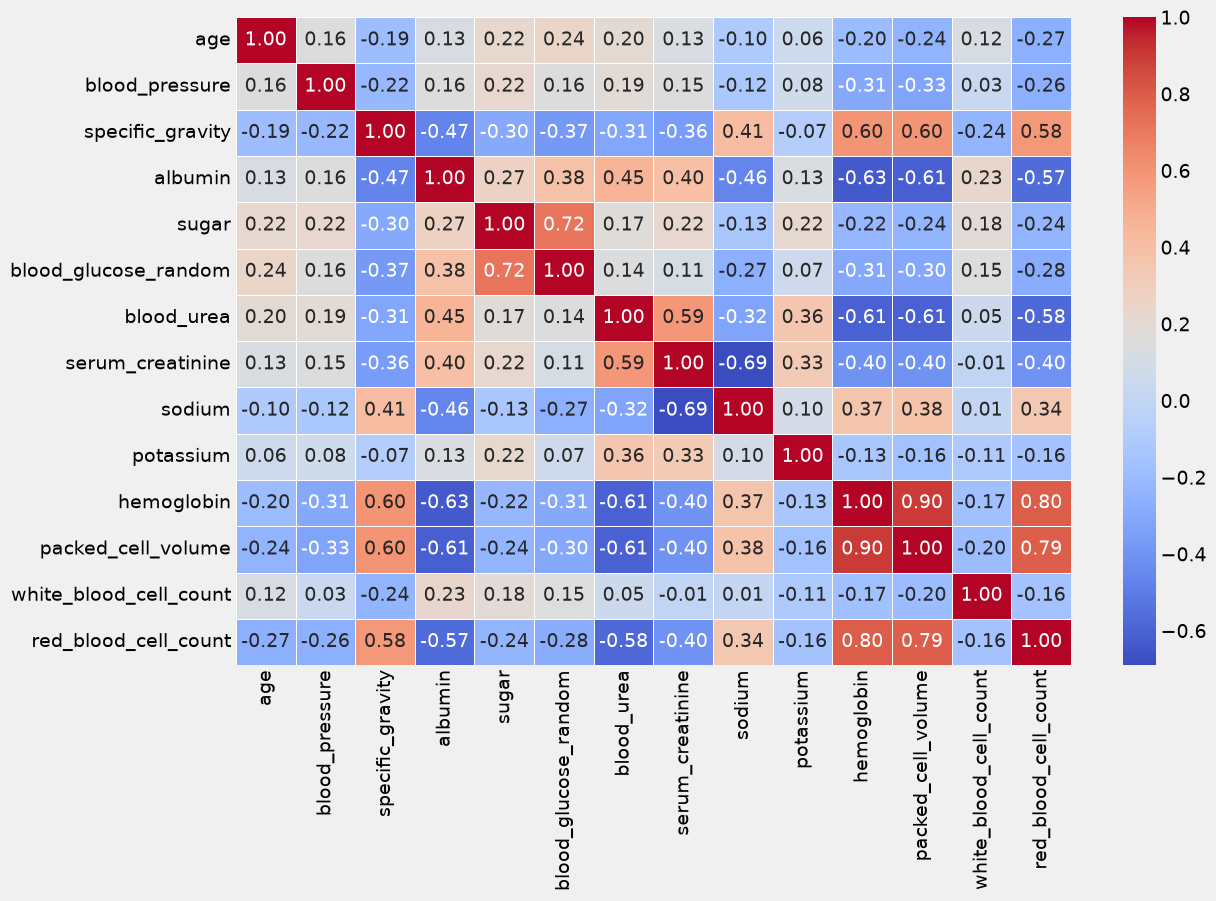

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df[numerical_cols].iloc[:,1:].corr(),
    annot=True,  # Shows correlation values inside cells
    cmap="coolwarm",  # Red/Blue color map
    fmt=".2f",  # Rounds values to 2 decimal places
    linewidths=0.5,
)